In [1]:
import os
import sys
import math
import warnings
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/scratch/wyz5rge/synthetic-hr/cmd_generator')
import interpolator

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# -----------------------------
# Simulation family
# -----------------------------
BASE_HIGH_DENSITY = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0'

SIM_PATHS = {
    0.01: os.path.join(BASE_HIGH_DENSITY, 'sfeff001_00') + '/',
    0.03: os.path.join(BASE_HIGH_DENSITY, 'sfeff003_00') + '/',
    0.10: os.path.join(BASE_HIGH_DENSITY, 'sfeff010_00') + '/',
    0.30: os.path.join(BASE_HIGH_DENSITY, 'sfeff030_00') + '/',
    1.00: os.path.join(BASE_HIGH_DENSITY, 'sfeff100_00') + '/',
}

EFF_VALUES = [0.01, 0.03, 0.10, 0.30, 1.00]

T_STAR_BY_EFF = {
    0.01: 19.40,
    0.03: 6.47,
    0.10: 1.94,
    0.30: 0.65,
    1.00: 0.19,
}

# -----------------------------
# Baraffe / SPISEA setup
# -----------------------------
AKs = 0.0
dist = 410
metallicity = 0.0

evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawHosek18b()

# Use a fresh cache directory for this notebook
iso_dir = '/scratch/wyz5rge/synthetic-hr/cmd_metric_isochrones'
os.makedirs(iso_dir, exist_ok=True)

# Generate ALL filters needed for this notebook at once
ALL_FILTERS = [
    'jwst,F115W',
    'jwst,F162M',
    'jwst,F182M',
    'jwst,F200W',
]

FILTER_KEY_MAP = {
    'jwst,F115W': 'm_jwst_F115W',
    'jwst,F162M': 'm_jwst_F162M',
    'jwst,F182M': 'm_jwst_F182M',
    'jwst,F200W': 'm_jwst_F200W',
}

# Alexandra’s temperature-bin edges
TEMP_BIN_EDGES = np.arange(3000, 3601, 100)

CMD_CHOICES = [
    ('jwst,F115W', 'jwst,F200W', 'jwst,F200W', 'F115W-F200W vs F200W'),
    ('jwst,F162M', 'jwst,F182M', 'jwst,F162M', 'F162M-F182M vs F162M'),
    ('jwst,F162M', 'jwst,F182M', 'jwst,F182M', 'F162M-F182M vs F182M'),
    ('jwst,F162M', 'jwst,F200W', 'jwst,F200W', 'F162M-F200W vs F200W'),
    ('jwst,F115W', 'jwst,F162M', 'jwst,F162M', 'F115W-F162M vs F162M'),
]

In [3]:
def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)
    if not sim_path.endswith('/'):
        sim_path += '/'

    snapshot = Reader.read_snapshot(sim_path, time=snapshot_time_myr)
    snapshot.to_physical()
    return converter.to_spicea_table(snapshot)


def extract_masses_and_ages(cluster_table):
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)
    ages_yr = ages_myr * 1e6
    return masses, ages_myr, ages_yr


def build_isochrone_grid(ages_yr, increment_yr=0.1e6, min_age_floor_yr=0.5e6):
    min_age = np.min(ages_yr)
    max_age = np.max(ages_yr)

    start = max(min_age_floor_yr, math.floor(min_age / increment_yr) * increment_yr)
    end = math.ceil(max_age / increment_yr) * increment_yr + increment_yr

    level_age_arr_yr = np.arange(start, end + 0.5 * increment_yr, increment_yr)
    log_age_arr = np.log10(level_age_arr_yr)

    iso_grid = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        iso_grid[i] = synthetic.IsochronePhot(
            log_age, AKs, dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=ALL_FILTERS,
            iso_dir=iso_dir
        )

    return level_age_arr_yr, log_age_arr, iso_grid

In [4]:
def safe_interpolate(age_myr, mass, iso_grid, log_age_arr, filters):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                return interpolator.interpolate(age_myr, mass, iso_grid, log_age_arr, filters)
    except Exception:
        return None

In [5]:
def interpolate_snapshot_cmd(cluster_table, filt_a, filt_b, y_filter_name, increment_yr=0.1e6):
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)

    level_age_arr_yr, log_age_arr, iso_grid = build_isochrone_grid(
        ages_yr,
        increment_yr=increment_yr
    )

    filt_key_a = FILTER_KEY_MAP[filt_a]
    filt_key_b = FILTER_KEY_MAP[filt_b]

    if y_filter_name == filt_a:
        y_filter_key = filt_key_a
    elif y_filter_name == filt_b:
        y_filter_key = filt_key_b
    else:
        raise ValueError("y_filter_name must equal filt_a or filt_b")

    rows = []
    for m, a in zip(masses, ages_myr):
        star = safe_interpolate(a, m, iso_grid, log_age_arr, [filt_key_a, filt_key_b])
        if star is None:
            continue

        lum = float(star[0])
        teff = float(star[1])
        logg = float(star[2])
        mag_a = float(star[3])
        mag_b = float(star[4])

        color = mag_a - mag_b
        ymag = mag_a if y_filter_key == filt_key_a else mag_b

        rows.append({
            'mass': m,
            'age_myr': a,
            'lum_watts': lum,
            'lum_lsun': lum / 3.846e26 if lum > 0 else np.nan,
            'teff': teff,
            'logg': logg,
            'mag_a': mag_a,
            'mag_b': mag_b,
            'color': color,
            'ymag': ymag,
        })

    df_cmd = pd.DataFrame(rows)
    return df_cmd, iso_grid, level_age_arr_yr, log_age_arr, (filt_key_a, filt_key_b), y_filter_key

In [6]:
def map_temp_edges_to_cmd_bins(fiducial_iso, filt_keys, y_filter_key, temp_edges=TEMP_BIN_EDGES):
    """
    On one fiducial isochrone, map Teff edges into CMD color positions.
    Also return the corresponding y positions.
    """
    pts = fiducial_iso.points
    teff = np.array(pts['Teff'], dtype=float)
    mag_a = np.array(pts[filt_keys[0]], dtype=float)
    mag_b = np.array(pts[filt_keys[1]], dtype=float)

    color = mag_a - mag_b
    ymag = mag_a if y_filter_key == filt_keys[0] else mag_b

    edge_colors = []
    edge_ymags = []

    for t in temp_edges:
        idx = np.argmin(np.abs(teff - t))
        edge_colors.append(color[idx])
        edge_ymags.append(ymag[idx])

    edge_colors = np.array(edge_colors)
    edge_ymags = np.array(edge_ymags)

    # For vertical bins, sort by color
    order = np.argsort(edge_colors)
    color_edges_sorted = edge_colors[order]

    # Broad y-window covering the mapped 3000–3600 K segment
    y_min = np.min(edge_ymags)
    y_max = np.max(edge_ymags)

    return {
        'edge_colors': edge_colors,
        'edge_ymags': edge_ymags,
        'color_edges_sorted': color_edges_sorted,
        'y_min': y_min,
        'y_max': y_max,
    }

In [7]:
def top_bottom_quartile_gap(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 4:
        return np.nan

    values = np.sort(values)
    q = max(1, len(values) // 4)

    bottom = values[:q]
    top = values[-q:]

    return np.mean(top) - np.mean(bottom)


def compute_cmd_metrics(df_cmd, cluster_table, color_edges_sorted, y_min, y_max):
    """
    CMD translation of Alexandra's metric:
    in each color bin, compute faintest25% mean - brightest25% mean in y-axis magnitude,
    then average across bins.
    """
    bin_spreads = []
    bin_means = []
    bin_counts = []

    for c_lo, c_hi in zip(color_edges_sorted[:-1], color_edges_sorted[1:]):
        sub = df_cmd[
            (df_cmd['color'] >= c_lo) &
            (df_cmd['color'] < c_hi) &
            (df_cmd['ymag'] >= min(y_min, y_max)) &
            (df_cmd['ymag'] <= max(y_min, y_max))
        ]

        if len(sub) < 4:
            continue

        yvals = sub['ymag'].values

        spread = top_bottom_quartile_gap(yvals)
        mean_y = np.mean(yvals)

        if np.isfinite(spread):
            bin_spreads.append(spread)
            bin_means.append(mean_y)
            bin_counts.append(len(sub))

    sigma_cmd = np.mean(bin_spreads) if len(bin_spreads) > 0 else np.nan
    mu_cmd = np.mean(bin_means) if len(bin_means) > 0 else np.nan

    _, ages_myr_raw, _ = extract_masses_and_ages(cluster_table)
    dt90 = np.percentile(ages_myr_raw, 95) - np.percentile(ages_myr_raw, 5) if len(ages_myr_raw) >= 2 else np.nan

    return {
        'sigma_cmd': sigma_cmd,
        'mu_cmd': mu_cmd,
        'dt90': dt90,
        'bin_spreads': np.array(bin_spreads),
        'bin_means': np.array(bin_means),
        'bin_counts': np.array(bin_counts),
        'n_temp_window_proxy': np.sum(bin_counts) if len(bin_counts) > 0 else 0,
    }

In [8]:
def plot_cmd_with_mapped_bins(sim_path, snapshot_time_myr, cmd_choice, fiducial_age_myr=None):
    filt_a, filt_b, y_filter_name, title = cmd_choice

    cluster_table = load_cluster_table(sim_path, snapshot_time_myr)
    df_cmd, iso_grid, level_age_arr_yr, log_age_arr, filt_keys, y_filter_key = interpolate_snapshot_cmd(
        cluster_table, filt_a, filt_b, y_filter_name
    )

    # Choose fiducial isochrone closest to requested age, else use middle of the grid
    if fiducial_age_myr is None:
        idx_fid = len(iso_grid) // 2
    else:
        grid_ages_myr = level_age_arr_yr / 1e6
        idx_fid = np.argmin(np.abs(grid_ages_myr - fiducial_age_myr))

    fid = iso_grid[idx_fid]
    mapping = map_temp_edges_to_cmd_bins(fid, filt_keys, y_filter_key)

    plt.figure(figsize=(7, 6))

    # Plot all isochrones lightly
    for i, iso in enumerate(iso_grid):
        pts = iso.points
        x = np.array(pts[filt_keys[0]] - pts[filt_keys[1]], dtype=float)
        y = np.array(pts[y_filter_key], dtype=float)
        plt.plot(x, y, color='lightcoral', alpha=0.15, lw=1)

    # Plot fiducial isochrone more strongly
    pts = fid.points
    x = np.array(pts[filt_keys[0]] - pts[filt_keys[1]], dtype=float)
    y = np.array(pts[y_filter_key], dtype=float)
    plt.plot(x, y, color='darkred', lw=2, label=f'fiducial isochrone (~{level_age_arr_yr[idx_fid]/1e6:.2f} Myr)')

    # Plot stars
    plt.scatter(df_cmd['color'], df_cmd['ymag'], s=5, alpha=0.5, color='k', label='cluster stars')

    # Plot vertical bin edges
    for c in mapping['color_edges_sorted']:
        plt.axvline(c, color='dodgerblue', alpha=0.5, lw=1.5)

    # Plot the mapped Teff points on the fiducial isochrone
    plt.scatter(mapping['edge_colors'], mapping['edge_ymags'], color='blue', s=40, zorder=5, label='mapped Teff edges')
    for t, c, yy in zip(TEMP_BIN_EDGES, mapping['edge_colors'], mapping['edge_ymags']):
        plt.text(c, yy, f'{t}', fontsize=8, ha='left', va='bottom')

    # y-window used for the metric
    x0 = np.min(mapping['color_edges_sorted'])
    x1 = np.max(mapping['color_edges_sorted'])
    y0 = min(mapping['y_min'], mapping['y_max'])
    y1 = max(mapping['y_min'], mapping['y_max'])

    rect = Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='blue', linewidth=2)
    plt.gca().add_patch(rect)

    plt.xlabel(f'{filt_a} - {filt_b}')
    plt.ylabel(y_filter_name)
    plt.title(f'{title}\n t={snapshot_time_myr:.2f} Myr')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

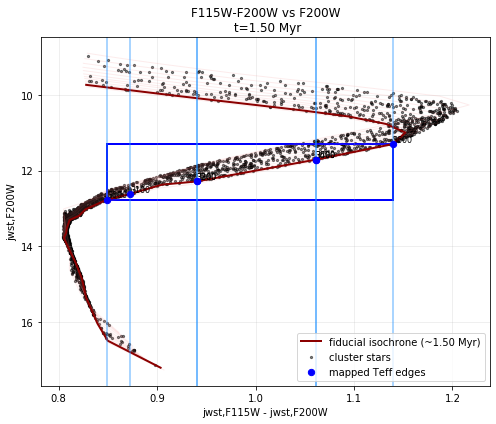

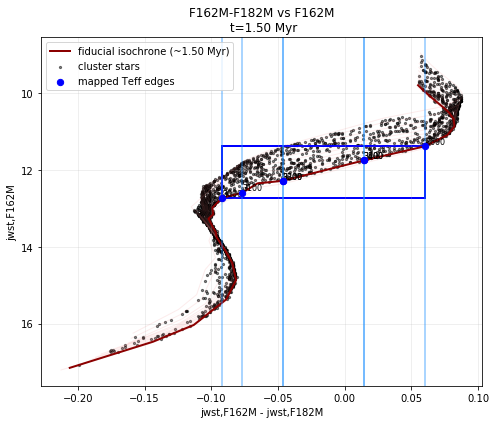

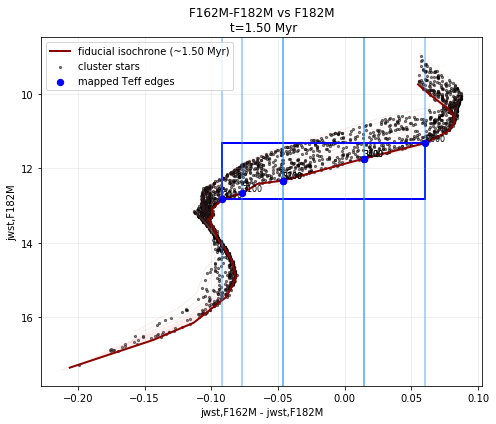

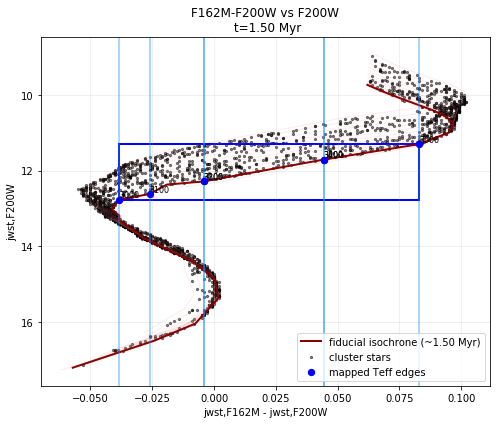

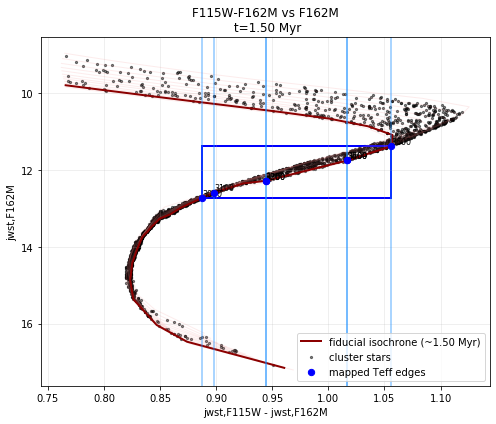

In [9]:
test_eff = 0.03
test_time = 1.5

for cmd_choice in CMD_CHOICES:
    plot_cmd_with_mapped_bins(
        SIM_PATHS[test_eff],
        test_time,
        cmd_choice,
        fiducial_age_myr=1.5
    )

In [10]:
cluster_table = load_cluster_table(SIM_PATHS[0.03], 1.5)
df_cmd, iso_grid, level_age_arr_yr, log_age_arr, filt_keys, y_filter_key = interpolate_snapshot_cmd(
    cluster_table,
    'jwst,F162M',
    'jwst,F182M',
    'jwst,F162M'
)

print("Returned filter keys:", filt_keys)
print("Returned y_filter_key:", y_filter_key)
print("Columns in isochrone points:")
print(iso_grid[0].points.colnames)

Returned filter keys: ('m_jwst_F162M', 'm_jwst_F182M')
Returned y_filter_key: m_jwst_F162M
Columns in isochrone points:
['L', 'Teff', 'R', 'mass', 'logg', 'isWR', 'mass_current', 'phase', 'm_jwst_F115W', 'm_jwst_F162M', 'm_jwst_F182M', 'm_jwst_F200W']


In [11]:
def build_cmd_time_series(sim_path, snapshot_times_myr, eff_label, cmd_choice, fiducial_age_myr=1.5):
    filt_a, filt_b, y_filter_name, title = cmd_choice
    rows = []

    # Build one fiducial mapping from a representative snapshot
    cluster_table_fid = load_cluster_table(sim_path, fiducial_age_myr)
    _, iso_grid_fid, level_age_arr_fid, _, filt_keys_fid, y_filter_key_fid = interpolate_snapshot_cmd(
        cluster_table_fid, filt_a, filt_b, y_filter_name
    )
    grid_ages_myr = level_age_arr_fid / 1e6
    idx_fid = np.argmin(np.abs(grid_ages_myr - fiducial_age_myr))
    mapping = map_temp_edges_to_cmd_bins(iso_grid_fid[idx_fid], filt_keys_fid, y_filter_key_fid)

    for t in snapshot_times_myr:
        try:
            cluster_table = load_cluster_table(sim_path, t)
            df_cmd, _, _, _, _, _ = interpolate_snapshot_cmd(cluster_table, filt_a, filt_b, y_filter_name)

            metrics = compute_cmd_metrics(
                df_cmd,
                cluster_table,
                mapping['color_edges_sorted'],
                mapping['y_min'],
                mapping['y_max']
            )

            rows.append({
                'eff': eff_label,
                't_myr': t,
                'dt90': metrics['dt90'],
                'sigma_cmd': metrics['sigma_cmd'],
                'mu_cmd': metrics['mu_cmd'],
                'cmd_title': title,
                'n_stars_cmd': len(df_cmd),
                'n_window': metrics['n_temp_window_proxy'],
            })

            print(f"{title}, e_ff={eff_label:.2f}, t={t:.2f} done")
        except Exception as e:
            print(f"{title}, e_ff={eff_label:.2f}, t={t:.2f} failed: {e}")

    return pd.DataFrame(rows)

F115W-F200W vs F200W, e_ff=0.03, t=0.50 failed: 'color'
F115W-F200W vs F200W, e_ff=0.03, t=0.75 done
F115W-F200W vs F200W, e_ff=0.03, t=1.00 done
F115W-F200W vs F200W, e_ff=0.03, t=1.25 done
F115W-F200W vs F200W, e_ff=0.03, t=1.50 done
Isochrone generation took 0.830466 s.
Making photometry for isochrone: log(t) = 6.23  AKs = 0.00  dist = 410
     Starting at:  2026-04-09 03:57:23.827461   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F115W = 18.24
Starting filter: jwst,F162M   Elapsed time: 0.74 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F162M = 17.26
Starting filter: jwst,F182M   Elapsed time: 1.48 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F182M = 17.48
Starting filter: jwst,F200W   Elapsed time: 2.22 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F200W = 17.33
      Time taken: 2.96 sec

Starting filter: jwst,F162M   Elapsed time: 0.74 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2167 K  m_jwst_F162M = 17.70
Starting filter: jwst,F182M   Elapsed time: 1.49 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2167 K  m_jwst_F182M = 17.96
Starting filter: jwst,F200W   Elapsed time: 2.23 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2167 K  m_jwst_F200W = 17.79
      Time taken: 2.98 seconds
F115W-F200W vs F200W, e_ff=0.03, t=2.50 done
Isochrone generation took 0.975568 s.
Making photometry for isochrone: log(t) = 6.45  AKs = 0.00  dist = 410
     Starting at:  2026-04-09 03:58:20.538881   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2161 K  m_jwst_F115W = 18.78
Starting filter: jwst,F162M   Elapsed time: 0.75 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2161 K  m_jwst_F162M = 17.72
Starting filter: jwst,F182M   Elapsed time: 1.4

Starting filter: jwst,F200W   Elapsed time: 2.24 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2084 K  m_jwst_F200W = 18.12
      Time taken: 2.98 seconds
Isochrone generation took 0.967526 s.
Making photometry for isochrone: log(t) = 6.58  AKs = 0.00  dist = 410
     Starting at:  2026-04-09 03:59:14.566291   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2076 K  m_jwst_F115W = 19.20
Starting filter: jwst,F162M   Elapsed time: 0.75 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2076 K  m_jwst_F162M = 18.04
Starting filter: jwst,F182M   Elapsed time: 1.50 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2076 K  m_jwst_F182M = 18.34
Starting filter: jwst,F200W   Elapsed time: 2.24 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2076 K  m_jwst_F200W = 18.14
      Time taken: 2.98 seconds
Isochrone generation took 0.960860 s.
Making photometry for i

Starting filter: jwst,F162M   Elapsed time: 0.74 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1975 K  m_jwst_F162M = 18.30
Starting filter: jwst,F182M   Elapsed time: 1.49 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1975 K  m_jwst_F182M = 18.67
Starting filter: jwst,F200W   Elapsed time: 2.24 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1975 K  m_jwst_F200W = 18.42
      Time taken: 3.00 seconds
Changing to logg=5.00 for T=  1960 logg=3.95
Isochrone generation took 0.969267 s.
Making photometry for isochrone: log(t) = 6.69  AKs = 0.00  dist = 410
     Starting at:  2026-04-09 04:00:11.485099   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1960 K  m_jwst_F115W = 19.81
Starting filter: jwst,F162M   Elapsed time: 0.87 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1960 K  m_jwst_F162M = 18.30
Starting filter: jwst,F182M   Elapsed time: 1.6

Starting filter: jwst,F162M   Elapsed time: 0.74 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1870 K  m_jwst_F162M = 18.57
Starting filter: jwst,F182M   Elapsed time: 1.48 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1870 K  m_jwst_F182M = 18.92
Starting filter: jwst,F200W   Elapsed time: 2.22 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1870 K  m_jwst_F200W = 18.65
      Time taken: 2.96 seconds
Changing to logg=5.00 for T=  1862 logg=3.98
Isochrone generation took 0.974984 s.
Making photometry for isochrone: log(t) = 6.79  AKs = 0.00  dist = 410
     Starting at:  2026-04-09 04:01:08.056523   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1862 K  m_jwst_F115W = 20.23
Starting filter: jwst,F162M   Elapsed time: 0.74 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1862 K  m_jwst_F162M = 18.61
Starting filter: jwst,F182M   Elapsed time: 1.4

F115W-F162M vs F162M, e_ff=0.03, t=5.75 done
F115W-F162M vs F162M, e_ff=0.03, t=6.00 done
F115W-F162M vs F162M, e_ff=0.03, t=6.25 done
F115W-F162M vs F162M, e_ff=0.03, t=6.50 done


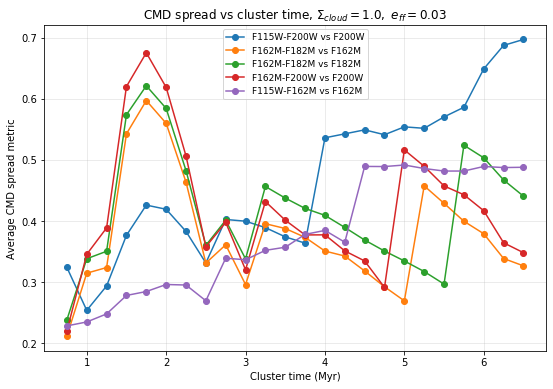

In [12]:
eff = 0.03
times = np.arange(0.5, 6.6, 0.25)

dfs_one_eff = []
for cmd_choice in CMD_CHOICES:
    dfs_one_eff.append(
        build_cmd_time_series(
            SIM_PATHS[eff],
            times,
            eff,
            cmd_choice,
            fiducial_age_myr=1.5
        )
    )

df_one_eff = pd.concat(dfs_one_eff, ignore_index=True)

plt.figure(figsize=(9, 6))
for title in df_one_eff['cmd_title'].unique():
    sub = df_one_eff[(df_one_eff['cmd_title'] == title) & np.isfinite(df_one_eff['sigma_cmd'])].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['sigma_cmd'], marker='o', label=title)

plt.xlabel('Cluster time (Myr)')
plt.ylabel('Average CMD spread metric')
plt.title(r'CMD spread vs cluster time, $\Sigma_{cloud}=1.0,\ e_{ff}=0.03$')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

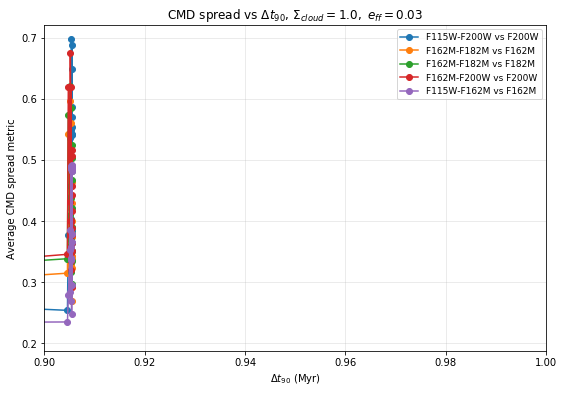

In [17]:
plt.figure(figsize=(9, 6))
for title in df_one_eff['cmd_title'].unique():
    sub = df_one_eff[(df_one_eff['cmd_title'] == title) & np.isfinite(df_one_eff['sigma_cmd'])].sort_values('dt90')
    plt.plot(sub['dt90'], sub['sigma_cmd'], marker='o', label=title)

plt.xlim(0.9, 1.0)
    
plt.xlabel(r'$\Delta t_{90}$ (Myr)')
plt.ylabel('Average CMD spread metric')
plt.title(r'CMD spread vs $\Delta t_{90}$, $\Sigma_{cloud}=1.0,\ e_{ff}=0.03$')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

In [14]:
all_cmd_dfs = []

for eff in EFF_VALUES:
    t_star = T_STAR_BY_EFF[eff]

    if eff == 0.01:
        times = np.arange(0.5, 10.1, 0.5)
    elif eff == 0.03:
        times = np.arange(0.5, 6.6, 0.25)
    elif eff == 0.10:
        times = np.arange(0.25, 2.1, 0.1)
    elif eff == 0.30:
        times = np.arange(0.10, 0.9, 0.05)
    elif eff == 1.00:
        times = np.arange(0.05, 0.5, 0.02)

    for cmd_choice in CMD_CHOICES:
        df_eff_cmd = build_cmd_time_series(
            SIM_PATHS[eff],
            times,
            eff,
            cmd_choice,
            fiducial_age_myr=1.5 if eff <= 0.03 else max(0.5, t_star)
        )
        all_cmd_dfs.append(df_eff_cmd)

df_cmd_all = pd.concat(all_cmd_dfs, ignore_index=True)

F115W-F200W vs F200W, e_ff=0.01, t=0.50 done
F115W-F200W vs F200W, e_ff=0.01, t=1.00 done
F115W-F200W vs F200W, e_ff=0.01, t=1.50 done
F115W-F200W vs F200W, e_ff=0.01, t=2.00 done
F115W-F200W vs F200W, e_ff=0.01, t=2.50 done
F115W-F200W vs F200W, e_ff=0.01, t=3.00 done
F115W-F200W vs F200W, e_ff=0.01, t=3.50 done
F115W-F200W vs F200W, e_ff=0.01, t=4.00 done
F115W-F200W vs F200W, e_ff=0.01, t=4.50 done
F115W-F200W vs F200W, e_ff=0.01, t=5.00 done
F115W-F200W vs F200W, e_ff=0.01, t=5.50 done
F115W-F200W vs F200W, e_ff=0.01, t=6.00 done
F115W-F200W vs F200W, e_ff=0.01, t=6.50 done
Changing to logg=5.00 for T=  1830 logg=4.00
Isochrone generation took 0.991588 s.
Making photometry for isochrone: log(t) = 6.83  AKs = 0.00  dist = 410
     Starting at:  2026-04-09 04:07:33.534061   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1830 K  m_jwst_F115W = 20.45
Starting filter: jwst,F162M   Elapsed time: 0.74 

Starting filter: jwst,F162M   Elapsed time: 0.75 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1692 K  m_jwst_F162M = 19.48
Starting filter: jwst,F182M   Elapsed time: 1.50 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1692 K  m_jwst_F182M = 19.41
Starting filter: jwst,F200W   Elapsed time: 2.25 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1692 K  m_jwst_F200W = 19.08
      Time taken: 3.01 seconds
Changing to logg=5.00 for T=  1677 logg=4.03
Isochrone generation took 0.974580 s.
Making photometry for isochrone: log(t) = 6.93  AKs = 0.00  dist = 410
     Starting at:  2026-04-09 04:08:26.526976   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1677 K  m_jwst_F115W = 21.37
Starting filter: jwst,F162M   Elapsed time: 0.75 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1677 K  m_jwst_F162M = 19.56
Starting filter: jwst,F182M   Elapsed time: 1.5

F162M-F182M vs F162M, e_ff=0.01, t=3.50 done
F162M-F182M vs F162M, e_ff=0.01, t=4.00 done
F162M-F182M vs F162M, e_ff=0.01, t=4.50 done
F162M-F182M vs F162M, e_ff=0.01, t=5.00 done
F162M-F182M vs F162M, e_ff=0.01, t=5.50 done
F162M-F182M vs F162M, e_ff=0.01, t=6.00 done
F162M-F182M vs F162M, e_ff=0.01, t=6.50 done
F162M-F182M vs F162M, e_ff=0.01, t=7.00 done
F162M-F182M vs F162M, e_ff=0.01, t=7.50 done
F162M-F182M vs F162M, e_ff=0.01, t=8.00 done
F162M-F182M vs F162M, e_ff=0.01, t=8.50 done
F162M-F182M vs F162M, e_ff=0.01, t=9.00 done
F162M-F182M vs F162M, e_ff=0.01, t=9.50 done
F162M-F182M vs F162M, e_ff=0.01, t=10.00 done
F162M-F182M vs F182M, e_ff=0.01, t=0.50 done
F162M-F182M vs F182M, e_ff=0.01, t=1.00 done
F162M-F182M vs F182M, e_ff=0.01, t=1.50 done
F162M-F182M vs F182M, e_ff=0.01, t=2.00 done
F162M-F182M vs F182M, e_ff=0.01, t=2.50 done
F162M-F182M vs F182M, e_ff=0.01, t=3.00 done
F162M-F182M vs F182M, e_ff=0.01, t=3.50 done
F162M-F182M vs F182M, e_ff=0.01, t=4.00 done
F162M-F18

F115W-F162M vs F162M, e_ff=0.03, t=2.25 done
F115W-F162M vs F162M, e_ff=0.03, t=2.50 done
F115W-F162M vs F162M, e_ff=0.03, t=2.75 done
F115W-F162M vs F162M, e_ff=0.03, t=3.00 done
F115W-F162M vs F162M, e_ff=0.03, t=3.25 done
F115W-F162M vs F162M, e_ff=0.03, t=3.50 done
F115W-F162M vs F162M, e_ff=0.03, t=3.75 done
F115W-F162M vs F162M, e_ff=0.03, t=4.00 done
F115W-F162M vs F162M, e_ff=0.03, t=4.25 done
F115W-F162M vs F162M, e_ff=0.03, t=4.50 done
F115W-F162M vs F162M, e_ff=0.03, t=4.75 done
F115W-F162M vs F162M, e_ff=0.03, t=5.00 done
F115W-F162M vs F162M, e_ff=0.03, t=5.25 done
F115W-F162M vs F162M, e_ff=0.03, t=5.50 done
F115W-F162M vs F162M, e_ff=0.03, t=5.75 done
F115W-F162M vs F162M, e_ff=0.03, t=6.00 done
F115W-F162M vs F162M, e_ff=0.03, t=6.25 done
F115W-F162M vs F162M, e_ff=0.03, t=6.50 done
F115W-F200W vs F200W, e_ff=0.10, t=0.25 failed: 'color'
F115W-F200W vs F200W, e_ff=0.10, t=0.35 failed: 'color'
F115W-F200W vs F200W, e_ff=0.10, t=0.45 failed: 'color'
F115W-F200W vs F200W, 

F162M-F200W vs F200W, e_ff=0.30, t=0.60 done
F162M-F200W vs F200W, e_ff=0.30, t=0.65 done
F162M-F200W vs F200W, e_ff=0.30, t=0.70 done
F162M-F200W vs F200W, e_ff=0.30, t=0.75 done
F162M-F200W vs F200W, e_ff=0.30, t=0.80 done
F162M-F200W vs F200W, e_ff=0.30, t=0.85 done
F115W-F162M vs F162M, e_ff=0.30, t=0.10 failed: 'color'
F115W-F162M vs F162M, e_ff=0.30, t=0.15 failed: 'color'
F115W-F162M vs F162M, e_ff=0.30, t=0.20 failed: 'color'
F115W-F162M vs F162M, e_ff=0.30, t=0.25 failed: 'color'
F115W-F162M vs F162M, e_ff=0.30, t=0.30 failed: 'color'
F115W-F162M vs F162M, e_ff=0.30, t=0.35 failed: 'color'
F115W-F162M vs F162M, e_ff=0.30, t=0.40 failed: 'color'
F115W-F162M vs F162M, e_ff=0.30, t=0.45 failed: 'color'
F115W-F162M vs F162M, e_ff=0.30, t=0.50 done
F115W-F162M vs F162M, e_ff=0.30, t=0.55 done
F115W-F162M vs F162M, e_ff=0.30, t=0.60 done
F115W-F162M vs F162M, e_ff=0.30, t=0.65 done
F115W-F162M vs F162M, e_ff=0.30, t=0.70 done
F115W-F162M vs F162M, e_ff=0.30, t=0.75 done
F115W-F162M 

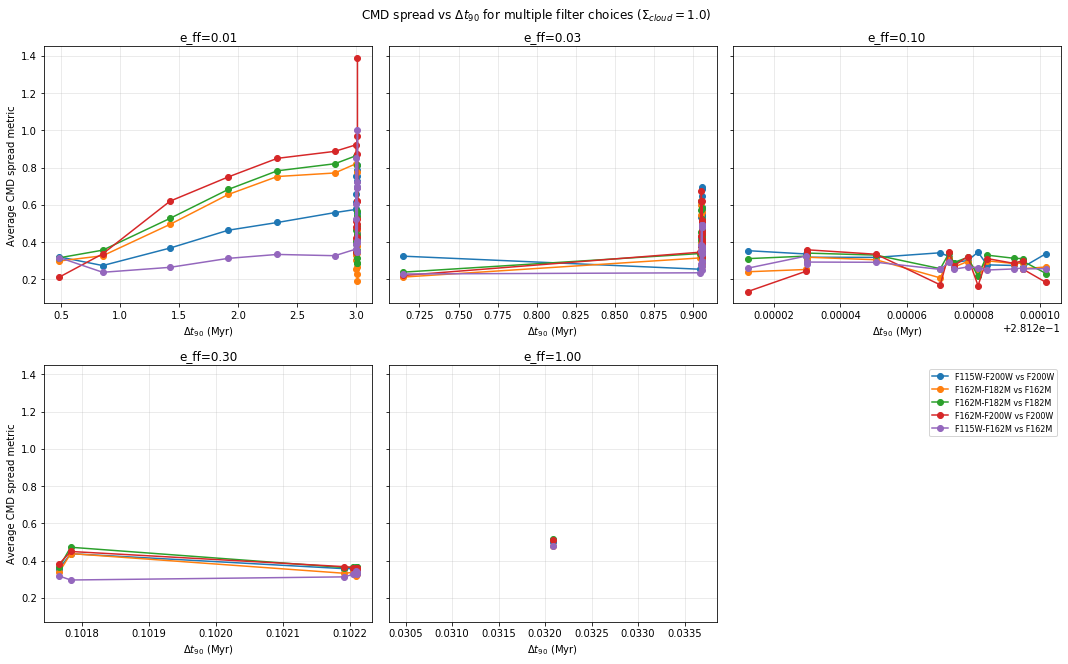

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
axes = axes.flatten()

for ax, eff in zip(axes, EFF_VALUES):
    subeff = df_cmd_all[df_cmd_all['eff'] == eff]

    for title in subeff['cmd_title'].unique():
        sub = subeff[(subeff['cmd_title'] == title) & np.isfinite(subeff['sigma_cmd'])].sort_values('dt90')
        ax.plot(sub['dt90'], sub['sigma_cmd'], marker='o', label=title)

    ax.set_title(f'e_ff={eff:.2f}')
    ax.set_xlabel(r'$\Delta t_{90}$ (Myr)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Average CMD spread metric')
axes[3].set_ylabel('Average CMD spread metric')

handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize=8, loc='best')
axes[-1].axis('off')

plt.suptitle(r'CMD spread vs $\Delta t_{90}$ for multiple filter choices ($\Sigma_{cloud}=1.0$)', y=1.02)
plt.tight_layout()
plt.show()

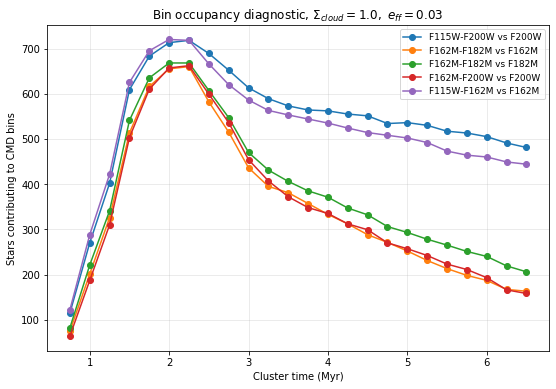

In [16]:
plt.figure(figsize=(9, 6))
for title in df_one_eff['cmd_title'].unique():
    sub = df_one_eff[df_one_eff['cmd_title'] == title].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['n_window'], marker='o', label=title)

plt.xlabel('Cluster time (Myr)')
plt.ylabel('Stars contributing to CMD bins')
plt.title(r'Bin occupancy diagnostic, $\Sigma_{cloud}=1.0,\ e_{ff}=0.03$')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()